In [1]:
import pandas as pd

#check match id overlap across tables

matches = pd.read_csv("tennis_MatchChartingProject-master/charting-m-matches-2020s.csv")
points_2020 = pd.read_csv("tennis_MatchChartingProject-master/charting-m-points-2020s.csv")

match_ids = set(matches['match_id'])
point2020_ids = set(points_2020['match_id'])

print("points with no matching match: ", len(point2020_ids) - len(match_ids))
print("matches with no point data: ", len(match_ids) - len(point2020_ids))


C:\Users\ramya\AppData\Local\Temp\ipykernel_8676\176476390.py:6: DtypeWarning: Columns (0: TbSet) have mixed types. Specify dtype option on import or set low_memory=False.
  points_2020 = pd.read_csv("tennis_MatchChartingProject-master/charting-m-points-2020s.csv")


points with no matching match:  -8
matches with no point data:  8


In [2]:
# missingness and coverage

matches = matches[matches['Date'].astype(str).str.match(r'^\d{8}$')]


matches['Date'] = pd.to_datetime(matches['Date'], format='%Y%m%d')
matches['year'] = matches['Date'].dt.year


## to see if we have enough spread
## grouped by year

print(matches.groupby('year')['match_id'].count())

## getting data from match_id in points table

parts = points_2020['match_id'].str.split('-')
points_2020['tourney'] = parts.str[2]
points_2020['round'] = parts.str[3]
points_2020['player_1'] = parts.str[4]
points_2020['player_2'] = parts.str[5]



#how many matches have point by point data

covered = matches[matches['match_id'].isin(point2020_ids)]
print(f"{len(covered)} / {len(matches)} matches have point data ") 


year
2020    170
2021    374
2022    648
2023    621
2024    769
2025    579
2026    184
Name: match_id, dtype: int64
3337 / 3345 matches have point data 


In [3]:
# class balance

## server win rate on points
## if servers win 65% of games they serve, thats the baseline the model has to beat

points_2020['server_won'] = (points_2020['Svr'] == points_2020['PtWinner']).astype(int)
print(points_2020['server_won'].mean())

# mean here is 0.64
# The momentum based model we're about to build should clear this bar in order to declare that momentum shifts predict wins

# higher ranked player win rate
# matches['higher_rank_won'] = matches['winner_rank'] < matches['loser_rank']
# print(matches['higher_rank_won'].mean())



0.6429390770040074


In [4]:
# eyeball full matches

sample_match = points_2020[points_2020['match_id'] == points_2020['match_id'].iloc[0]].sort_values('Pt')
print(sample_match[['Pt', 'Set1', 'Set2', 'Gm1','Gm2', 'Svr','PtWinner']].to_string())

      Pt  Set1  Set2  Gm1  Gm2  Svr  PtWinner
50     1     0     0    0  0.0    1         1
51     2     0     0    0  0.0    1         2
52     3     0     0    0  0.0    1         2
53     4     0     0    0  0.0    1         1
54     5     0     0    0  0.0    1         1
55     6     0     0    0  0.0    1         2
56     7     0     0    0  0.0    1         1
57     8     0     0    0  0.0    1         1
58     9     0     0    1  0.0    2         2
59    10     0     0    1  0.0    2         1
60    11     0     0    1  0.0    2         2
61    12     0     0    1  0.0    2         2
62    13     0     0    1  0.0    2         2
63    14     0     0    1  1.0    1         2
64    15     0     0    1  1.0    1         1
65    16     0     0    1  1.0    1         1
66    17     0     0    1  1.0    1         1
67    18     0     0    1  1.0    1         2
68    19     0     0    1  1.0    1         2
69    20     0     0    1  1.0    1         2
70    21     0     0    1  1.0    

['match_id', 'Pt', 'Set1', 'Set2', 'Gm1', 'Gm2', 'Pts', 'Gm#', 'TbSet', 'Svr', '1st', '2nd', 'Notes', 'PtWinner', 'tourney', 'round', 'player_1', 'player_2', 'server_won']


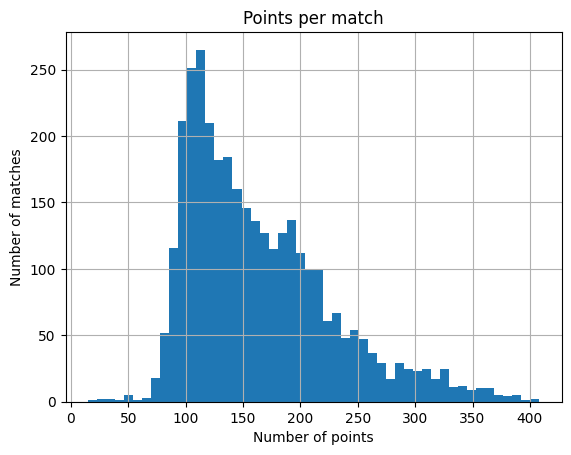

In [5]:
# plot distributions

import matplotlib.pyplot as plt


print(points_2020.columns.tolist())
"""
points_2020.groupby('match_id').size().hist(bins=50)
plt.title('Points per match')
plt.show()

# Rally length if you have shot counts
points_2020['rally_length'].hist(bins=30)
plt.show()
"""
import matplotlib.pyplot as plt

# Points per match
points_2020.groupby('match_id').size().hist(bins=50)

plt.title('Points per match')
plt.xlabel('Number of points')
plt.ylabel('Number of matches')
plt.show()

In [6]:
#### Dataset: N matches, M with point-level data, years X–Y. Server win rate: ~65%. 
#### Higher-ranked player wins ~68% of matches. Limitation: point data missing for [X]% of matches, mostly [reason].

In [7]:
# Row count per match - flag anything weird
match_lengths = points_2020.groupby('match_id').size()
print(match_lengths.describe())
print("\nSuspiciously short matches:", (match_lengths < 40).sum())
print("Suspiciously long matches:", (match_lengths > 300).sum())

# Winner column - any values besides 1 or 2?
print("\nUnique winner values:", points_2020['PtWinner'].unique())
print("Unique server values:", points_2020['Svr'].unique())

short_matches = match_lengths[match_lengths < 40]
print(short_matches)

long_matches = match_lengths[match_lengths > 300]
print(long_matches)

count    3337.000000
mean      164.062931
std        63.203467
min        15.000000
25%       115.000000
50%       149.000000
75%       198.000000
max       408.000000
dtype: float64

Suspiciously short matches: 6
Suspiciously long matches: 152

Unique winner values: [2 1]
Unique server values: [2 1]
match_id
20210113-M-Antalya-F-Alex_De_Minaur-Alexander_Bublik               15
20220330-M-Miami_Masters-QF-Francisco_Cerundolo-Jannik_Sinner      33
20240504-M-Madrid_Masters-SF-Jiri_Lehecka-Felix_Auger_Aliassime    34
20250105-M-Brisbane-F-Jiri_Lehecka-Reilly_Opelka                   24
20250131-M-Montpellier-QF-Nikoloz_Basilashvili-Andrey_Rublev       39
20250818-M-Cincinnati_Masters-F-Jannik_Sinner-Carlos_Alcaraz       29
dtype: int64
match_id
20200121-M-Australian_Open-R128-Casper_Ruud-Egor_Gerasimov               327
20200121-M-Australian_Open-R128-Marc_Polmans-Mikhail_Kukushkin           346
20200124-M-Australian_Open-R32-John_Millman-Roger_Federer                359
20200128-M-Austr

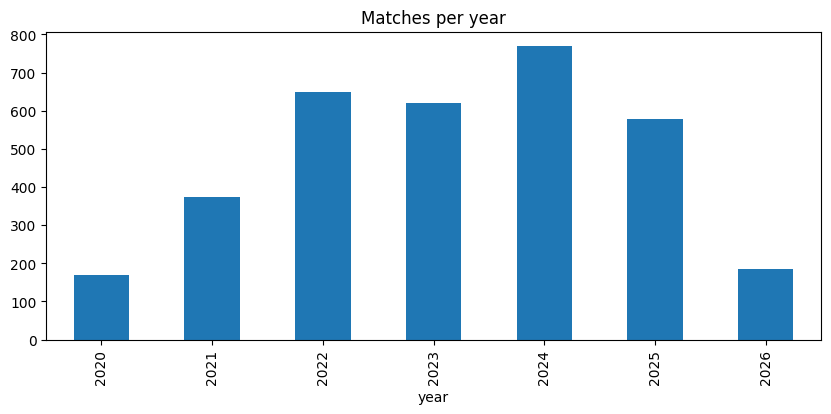

In [8]:
import matplotlib.pyplot as plt
matches['year'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.title('Matches per year')
plt.show()

In [9]:
print("Total matches:", matches['match_id'].nunique())
print("Total points:", len(points_2020))
print("Date range:", matches['Date'].min(), "to", matches['Date'].max())



Total matches: 3345
Total points: 547478
Date range: 2020-01-03 00:00:00 to 2026-05-21 00:00:00


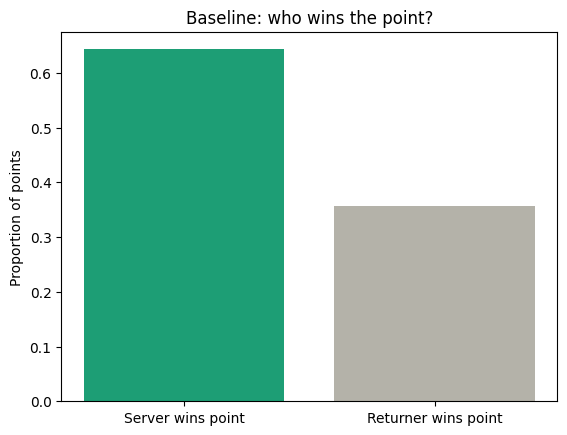

In [10]:
import matplotlib.pyplot as plt

rate = points_2020['server_won'].mean()
plt.bar(['Server wins point', 'Returner wins point'], [rate, 1-rate], color=['#1D9E75', '#B4B2A9'])
plt.title('Baseline: who wins the point?')
plt.ylabel('Proportion of points')
plt.savefig('baseline_server_win_rate.png')
plt.show()


In [11]:

df = points_2020.copy()


df['server_won'] = (df['Svr'] == df['PtWinner']).astype(int)


df['point_in_game'] = df.groupby(['match_id', 'Set1', 'Set2', 'Gm1', 'Gm2']).cumcount() + 1
one_match_id = points_2020['match_id'].iloc[0]
sample = df[df['match_id'] == one_match_id].sort_values('Pt')

print(sample[['Pt', 'Set1', 'Set2', 'Gm1', 'Gm2', 'Svr', 'PtWinner', 'point_in_game']].to_string())

# Get the last point_in_game value for each game (i.e., how many points that game took)
game_lengths = df[df['match_id'] == one_match_id].groupby(['Set1','Set2','Gm1','Gm2'])['point_in_game'].max()

# Sum across all games
total_from_games = game_lengths.sum()

# Compare to the actual last point number in the match
total_from_pt = df[df['match_id'] == one_match_id]['Pt'].max()

print(total_from_games, total_from_pt)
print("Match!" if total_from_games == total_from_pt else "Mismatch!")

      Pt  Set1  Set2  Gm1  Gm2  Svr  PtWinner  point_in_game
50     1     0     0    0  0.0    1         1            1.0
51     2     0     0    0  0.0    1         2            2.0
52     3     0     0    0  0.0    1         2            3.0
53     4     0     0    0  0.0    1         1            4.0
54     5     0     0    0  0.0    1         1            5.0
55     6     0     0    0  0.0    1         2            6.0
56     7     0     0    0  0.0    1         1            7.0
57     8     0     0    0  0.0    1         1            8.0
58     9     0     0    1  0.0    2         2            1.0
59    10     0     0    1  0.0    2         1            2.0
60    11     0     0    1  0.0    2         2            3.0
61    12     0     0    1  0.0    2         2            4.0
62    13     0     0    1  0.0    2         2            5.0
63    14     0     0    1  1.0    1         2            1.0
64    15     0     0    1  1.0    1         1            2.0
65    16     0     0    

count    3337.000000
mean      164.062931
std        63.203467
min        15.000000
25%       115.000000
50%       149.000000
75%       198.000000
max       408.000000
dtype: float64
Any remaining matches under 40 points: 6


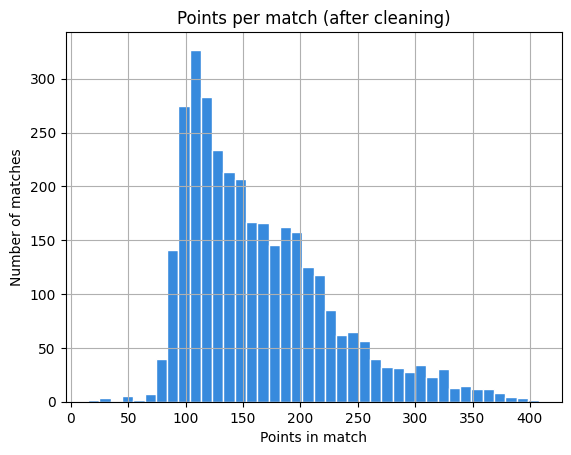

In [12]:
points_per_match = points_2020.groupby('match_id').size()
print(points_per_match.describe())
print("Any remaining matches under 40 points:", (points_per_match < 40).sum())
import matplotlib.pyplot as plt

points_per_match.hist(bins=40, color='#378ADD', edgecolor='white')
plt.title('Points per match (after cleaning)')
plt.xlabel('Points in match')
plt.ylabel('Number of matches')
plt.savefig('points_per_match_distribution.png')
plt.show()

In [13]:
points_2020.head()

,match_id,Pt,Set1,Set2,Gm1,Gm2,Pts,Gm#,TbSet,Svr,1st,2nd,Notes,PtWinner,tourney,round,player_1,player_2,server_won
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,92,0,1,1,0.0,0-15,14,True,2,4b37y1r3n#,NaN,NaN,2,Roland_Garros,Q3,Jesper_De_Jong,Michael_Zheng,1
1,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,93,0,1,1,0.0,15-15,14,True,2,6n,5f18f1f1f3s3f-1l3*,NaN,1,Roland_Garros,Q3,Jesper_De_Jong,Michael_Zheng,0
2,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,94,0,1,1,0.0,15-30,14,True,2,4*,NaN,NaN,2,Roland_Garros,Q3,Jesper_De_Jong,Michael_Zheng,1
3,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,95,0,1,1,0.0,30-30,14,True,2,6b3n#,NaN,NaN,2,Roland_Garros,Q3,Jesper_De_Jong,Michael_Zheng,1
4,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,96,0,1,1,0.0,40-30,14,True,2,6f18f3d@,NaN,NaN,1,Roland_Garros,Q3,Jesper_De_Jong,Michael_Zheng,0


In [14]:
points_2020.info()

<class 'pandas.DataFrame'>
RangeIndex: 547478 entries, 0 to 547477
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   match_id    547478 non-null  str    
 1   Pt          547478 non-null  int64  
 2   Set1        547478 non-null  int64  
 3   Set2        547478 non-null  int64  
 4   Gm1         547478 non-null  int64  
 5   Gm2         547477 non-null  float64
 6   Pts         547478 non-null  str    
 7   Gm#         547478 non-null  int64  
 8   TbSet       547477 non-null  object 
 9   Svr         547478 non-null  int64  
 10  1st         547478 non-null  str    
 11  2nd         201962 non-null  str    
 12  Notes       76345 non-null   str    
 13  PtWinner    547478 non-null  int64  
 14  tourney     547478 non-null  object 
 15  round       547478 non-null  object 
 16  player_1    547478 non-null  object 
 17  player_2    547478 non-null  object 
 18  server_won  547478 non-null  int64  
dtypes: float64(1)

In [15]:
points_2020["server_won"].value_counts(dropna=False)

server_won
1    351995
0    195483
Name: count, dtype: int64

In [16]:
points_2020.groupby("match_id").size().describe()

count    3337.000000
mean      164.062931
std        63.203467
min        15.000000
25%       115.000000
50%       149.000000
75%       198.000000
max       408.000000
dtype: float64

In [17]:
points_2020["PtWinner"].value_counts(dropna=False)

PtWinner
1    275853
2    271625
Name: count, dtype: int64

In [18]:
points_2020["p1_won"] = (points_2020["PtWinner"] == 1).astype(int)

points_2020[["match_id", "Pt", "PtWinner", "p1_won"]].head(10)

,match_id,Pt,PtWinner,p1_won
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,92,2,0
1,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,93,1,1
2,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,94,2,0
3,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,95,2,0
4,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,96,1,1
5,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,97,2,0
6,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,98,2,0
7,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,99,1,1
8,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,100,2,0
9,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,101,1,1


In [19]:
points_2020["momentum_5"] = (
    points_2020
    .groupby("match_id")["p1_won"]
    .transform(lambda x: 2 * x.shift(1).rolling(5).mean() - 1)
)

In [20]:
points_2020[
    ["match_id", "Pt", "p1_won", "momentum_5"]
].head(15)

,match_id,Pt,p1_won,momentum_5
0,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,92,0,NaN
1,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,93,1,NaN
2,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,94,0,NaN
3,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,95,0,NaN
4,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,96,1,NaN
5,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,97,0,-0.2
6,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,98,0,-0.2
7,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,99,1,-0.6
8,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,100,0,-0.2
9,20260521-M-Roland_Garros-Q3-Jesper_De_Jong-Mic...,101,1,-0.2


In [21]:
(points_2020.groupby("match_id")["Pt"]
          .apply(lambda x: x.is_monotonic_increasing)
          .value_counts())

Pt
True     2740
False     597
Name: count, dtype: int64

In [22]:
points_2020 = points_2020.sort_values(
    ["match_id", "Pt"]
).reset_index(drop=True)

In [23]:
(points_2020.groupby("match_id")["Pt"]
          .apply(lambda x: x.is_monotonic_increasing)
          .value_counts())

Pt
True    3337
Name: count, dtype: int64

In [24]:
duplicate_points = (
    points_2020.groupby(["match_id", "Pt"])
             .size()
             .gt(1)
             .sum()
)



In [25]:
duplicate_points

np.int64(280)

In [26]:
duplicates = (
    points_2020[
        points_2020.duplicated(["match_id", "Pt"], keep=False)
    ]
    .sort_values(["match_id", "Pt"])
)

duplicates[
    ["match_id", "Pt", "Set1", "Set2", "Gm1", "Gm2",
     "Pts", "Gm#", "Svr", "PtWinner"]
].head(30)

,match_id,Pt,Set1,Set2,Gm1,Gm2,Pts,Gm#,Svr,PtWinner
161352,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,1,0,0,0,0.0,0-0,1,1,1
161353,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,1,0,0,0,0.0,0-0,1,1,1
161354,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,2,0,0,0,0.0,15-0,1,1,1
161355,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,2,0,0,0,0.0,15-0,1,1,1
161356,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,3,0,0,0,0.0,30-0,1,1,2
161357,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,3,0,0,0,0.0,30-0,1,1,2
161358,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,4,0,0,0,0.0,30-15,1,1,2
161359,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,4,0,0,0,0.0,30-15,1,1,2
161360,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,5,0,0,0,0.0,30-30,1,1,1
161361,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,5,0,0,0,0.0,30-30,1,1,1


In [27]:
duplicates = (
    points_2020[
        points_2020.duplicated(["match_id", "Pt"], keep=False)
    ]
    .sort_values(["match_id", "Pt"])
)

duplicates[
    ["match_id", "Pt", "Set1", "Set2", "Gm1", "Gm2",
     "Pts", "Gm#", "Svr", "PtWinner"]
].head(30)

,match_id,Pt,Set1,Set2,Gm1,Gm2,Pts,Gm#,Svr,PtWinner
161352,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,1,0,0,0,0.0,0-0,1,1,1
161353,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,1,0,0,0,0.0,0-0,1,1,1
161354,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,2,0,0,0,0.0,15-0,1,1,1
161355,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,2,0,0,0,0.0,15-0,1,1,1
161356,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,3,0,0,0,0.0,30-0,1,1,2
161357,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,3,0,0,0,0.0,30-0,1,1,2
161358,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,4,0,0,0,0.0,30-15,1,1,2
161359,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,4,0,0,0,0.0,30-15,1,1,2
161360,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,5,0,0,0,0.0,30-30,1,1,1
161361,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,5,0,0,0,0.0,30-30,1,1,1


In [28]:
print(
    duplicates[
        ["match_id", "Pt", "Set1", "Set2", "Gm1", "Gm2",
         "Pts", "Gm#", "Svr", "PtWinner"]
    ].head(30).to_string(index=False)
)

                                                match_id  Pt  Set1  Set2  Gm1  Gm2   Pts  Gm#  Svr  PtWinner
20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios   1     0     0    0  0.0   0-0    1    1         1
20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios   1     0     0    0  0.0   0-0    1    1         1
20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios   2     0     0    0  0.0  15-0    1    1         1
20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios   2     0     0    0  0.0  15-0    1    1         1
20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios   3     0     0    0  0.0  30-0    1    1         2
20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios   3     0     0    0  0.0  30-0    1    1         2
20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios   4     0     0    0  0.0 30-15    1    1         2
20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios   4     0     0    0  0.0 30-15    1    1         2
20220812-M-Canada_M

In [29]:
points_2020[
    (points_2020["match_id"] == "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios") &
    (points_2020["Pt"] == 1)
].T


,161352,161353
match_id,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...
Pt,1,1
Set1,0,0
Set2,0,0
Gm1,0,0
Gm2,0.0,0.0
Pts,0-0,0-0
Gm#,1,1
TbSet,True,True
Svr,1,1


In [30]:
print("Total rows:", len(points_2020))
print("Exact duplicate rows:", points_2020.duplicated().sum())
print("Rows after deduplication:", len(points_2020.drop_duplicates()))

Total rows: 547478
Exact duplicate rows: 78
Rows after deduplication: 547400


In [31]:
print(
    "Percentage of rows that are exact duplicates:",
    round(points_2020.duplicated().mean() * 100, 2),
    "%"
)

Percentage of rows that are exact duplicates: 0.01 %


In [32]:
points_2020 = points_2020.drop_duplicates().copy()

print(points_2020.shape)

(547400, 21)


In [33]:
points_2020["match_id"].nunique()


3337

In [34]:
points_2020.groupby("match_id").size().describe()

count    3337.000000
mean      164.039556
std        63.211496
min        15.000000
25%       115.000000
50%       149.000000
75%       198.000000
max       403.000000
dtype: float64

In [35]:
points_2020.columns.tolist()

['match_id',
 'Pt',
 'Set1',
 'Set2',
 'Gm1',
 'Gm2',
 'Pts',
 'Gm#',
 'TbSet',
 'Svr',
 '1st',
 '2nd',
 'Notes',
 'PtWinner',
 'tourney',
 'round',
 'player_1',
 'player_2',
 'server_won',
 'p1_won',
 'momentum_5']

In [36]:
points_2020[[
    "Pt",
    "PtWinner",
    "momentum_5",
    "p1_won"
]].head(20)

,Pt,PtWinner,momentum_5,p1_won
0,1,2,NaN,0
1,2,2,NaN,0
2,3,1,NaN,1
3,4,2,NaN,0
4,5,1,NaN,1
5,6,2,-0.2,0
6,7,2,-0.2,0
7,8,2,-0.2,0
8,9,2,-0.6,0
9,10,2,-0.6,0


In [37]:
points_2020["momentum_5"].value_counts(dropna=False).head(20)
print("hello")

hello


In [38]:
points_2020[
    points_2020["match_id"] == "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios"
][[
    "Pt", "PtWinner", "momentum_5", "p1_won"
]].head(15).to_string(index=False)

' Pt  PtWinner  momentum_5  p1_won\n  1         1         NaN       1\n  1         1         0.6       1\n  2         1         NaN       1\n  2         1         0.6       1\n  3         2         NaN       0\n  3         2         0.6       0\n  4         2         NaN       0\n  4         2         0.2       0\n  5         1         NaN       1\n  5         1        -0.2       1\n  6         1         0.2       1\n  6         1         0.2       1\n  7         2         0.2       0\n  7         2         0.2       0\n  8         1        -0.2       1'

In [39]:
df = points_2020.copy()

df = df.drop(columns=["momentum_5"])

In [40]:
df = df.sort_values(["match_id", "Pt"]).reset_index(drop=True)

In [41]:
df["point_p1"] = df["PtWinner"].map({
    1: 1,
    2: -1
})

In [42]:
df["momentum_5"] = (
    df.groupby("match_id")["point_p1"]
      .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [43]:
df = points_2020.copy()
df = df.drop(columns=["momentum_5"])
df = df.sort_values(["match_id", "Pt"]).reset_index(drop=True)

df["point_p1"] = df["PtWinner"].map({
    1: 1,
    2: -1
})

In [44]:
df[
    df["match_id"] == "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios"
][["Pt", "PtWinner", "point_p1"]].head(15)

,Pt,PtWinner,point_p1
161352,1,1,1
161353,1,1,1
161354,2,1,1
161355,2,1,1
161356,3,2,-1
161357,3,2,-1
161358,4,2,-1
161359,4,2,-1
161360,5,1,1
161361,5,1,1


In [45]:
df[
    (df["match_id"] == "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios") &
    (df["Pt"] == 1)
].T

,161352,161353
match_id,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...,20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Ni...
Pt,1,1
Set1,0,0
Set2,0,0
Gm1,0,0
Gm2,0.0,0.0
Pts,0-0,0-0
Gm#,1,1
TbSet,True,True
Svr,1,1


In [46]:
pt_counts = (
    df.groupby(["match_id", "Pt"])
      .size()
)

print(pt_counts.value_counts().sort_index())

1    546996
2       202
Name: count, dtype: int64


In [47]:
df_points = (
    df.sort_values(["match_id", "Pt"])
      .drop_duplicates(["match_id", "Pt"], keep="first")
      .reset_index(drop=True)
)

In [48]:
print("Rows:", len(df_points))
print("Unique match-point combinations:",
      df_points[["match_id", "Pt"]].drop_duplicates().shape[0])

print(
    "Duplicate match-point combinations:",
    df_points.duplicated(["match_id", "Pt"]).sum()
)

Rows: 547198
Unique match-point combinations: 547198
Duplicate match-point combinations: 0


In [49]:
df_points["point_p1"] = df_points["PtWinner"].map({
    1: 1,
    2: -1
})

In [50]:
df_points["momentum_5"] = (
    df_points
    .groupby("match_id")["point_p1"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [51]:
df_points[
    df_points["match_id"] ==
    "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios"
][["Pt", "PtWinner", "point_p1", "momentum_5"]].head(12)

,Pt,PtWinner,point_p1,momentum_5
161352,1,1,1,NaN
161353,2,1,1,NaN
161354,3,2,-1,NaN
161355,4,2,-1,NaN
161356,5,1,1,NaN
161357,6,1,1,0.2
161358,7,2,-1,0.2
161359,8,1,1,-0.2
161360,9,2,-1,0.2
161361,10,2,-1,0.2


In [52]:
df_points["momentum_10"] = (
    df_points
    .groupby("match_id")["point_p1"]
    .transform(lambda x: x.shift(1).rolling(10).mean())
)

In [53]:
df_points[
    df_points["match_id"] ==
    "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios"
][["Pt", "PtWinner", "point_p1", "momentum_5", "momentum_10"]].head(15)

,Pt,PtWinner,point_p1,momentum_5,momentum_10
161352,1,1,1,NaN,NaN
161353,2,1,1,NaN,NaN
161354,3,2,-1,NaN,NaN
161355,4,2,-1,NaN,NaN
161356,5,1,1,NaN,NaN
161357,6,1,1,0.2,NaN
161358,7,2,-1,0.2,NaN
161359,8,1,1,-0.2,NaN
161360,9,2,-1,0.2,NaN
161361,10,2,-1,0.2,NaN


In [54]:
def calculate_streak(x):
    streak = []
    current = 0

    for value in x:
        streak.append(current)

        if value == 1:
            current = current + 1 if current > 0 else 1
        else:
            current = current - 1 if current < 0 else -1

    return streak


df_points["current_streak"] = (
    df_points
    .groupby("match_id")["point_p1"]
    .transform(calculate_streak)
)

In [55]:
df_points[
    df_points["match_id"] ==
    "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios"
][["Pt", "PtWinner", "point_p1", "current_streak"]].head(15)

,Pt,PtWinner,point_p1,current_streak
161352,1,1,1,0
161353,2,1,1,1
161354,3,2,-1,2
161355,4,2,-1,-1
161356,5,1,1,-2
161357,6,1,1,1
161358,7,2,-1,2
161359,8,1,1,-1
161360,9,2,-1,1
161361,10,2,-1,-1


In [56]:
df_points["game_score_diff"] = (
    df_points["Gm1"] - df_points["Gm2"]
)

In [57]:
df_points[
    df_points["match_id"] ==
    "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios"
][["Pt", "Gm1", "Gm2", "game_score_diff"]].head(20)

,Pt,Gm1,Gm2,game_score_diff
161352,1,0,0.0,0.0
161353,2,0,0.0,0.0
161354,3,0,0.0,0.0
161355,4,0,0.0,0.0
161356,5,0,0.0,0.0
161357,6,0,0.0,0.0
161358,7,1,0.0,1.0
161359,8,1,0.0,1.0
161360,9,1,0.0,1.0
161361,10,1,0.0,1.0


In [58]:
df_points["set_score_diff"] = (
    df_points["Set1"] - df_points["Set2"]
)

In [59]:
df_points[
    df_points["match_id"] ==
    "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios"
][[
    "Pt",
    "Set1",
    "Set2",
    "set_score_diff"
]].head(30)

,Pt,Set1,Set2,set_score_diff
161352,1,0,0,0
161353,2,0,0,0
161354,3,0,0,0
161355,4,0,0,0
161356,5,0,0,0
161357,6,0,0,0
161358,7,0,0,0
161359,8,0,0,0
161360,9,0,0,0
161361,10,0,0,0


In [60]:
features = [
    "momentum_5",
    "momentum_10",
    "current_streak",
    "game_score_diff",
    "set_score_diff"
]

target = "p1_won"

In [61]:
features = [
    "momentum_5",
    "momentum_10",
    "current_streak",
    "game_score_diff",
    "set_score_diff"
]

target = "p1_won"

print("Total rows:", len(df_points))

print("Rows with missing values:")
print(df_points[features].isna().sum())

print("\nRows remaining after dropping NaNs:",
      df_points[features].dropna().shape[0])

Total rows: 547198
Rows with missing values:
momentum_5         16685
momentum_10        33370
current_streak         0
game_score_diff        1
set_score_diff         0
dtype: int64

Rows remaining after dropping NaNs: 513827


In [62]:
df_model = df_points.dropna(subset=features).copy()

In [63]:
print(df_model.shape)
print(df_model[features].isna().sum())

(513827, 26)
momentum_5         0
momentum_10        0
current_streak     0
game_score_diff    0
set_score_diff     0
dtype: int64


In [64]:
print("Number of matches:", df_model["match_id"].nunique())

Number of matches: 3337


In [65]:
print(
    df_model.groupby("match_id")["p1_won"]
    .first()
    .value_counts()
)


p1_won
0    1709
1    1628
Name: count, dtype: int64


In [66]:
from sklearn.model_selection import train_test_split

match_ids = df_model["match_id"].unique()

train_matches, test_matches = train_test_split(
    match_ids,
    test_size=0.20,
    random_state=42,
    stratify=df_model.groupby("match_id")["p1_won"].first()
)

In [67]:
train_df = df_model[
    df_model["match_id"].isin(train_matches)
].copy()

test_df = df_model[
    df_model["match_id"].isin(test_matches)
].copy()

In [68]:
print("Train matches:", train_df["match_id"].nunique())
print("Test matches:", test_df["match_id"].nunique())

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print("\nTrain target:")
print(train_df["p1_won"].value_counts())

print("\nTest target:")
print(test_df["p1_won"].value_counts())

print(
    "\nOverlap:",
    len(set(train_matches) & set(test_matches))
)

Train matches: 2669
Test matches: 668
Train rows: 410158
Test rows: 103669

Train target:
p1_won
1    205531
0    204627
Name: count, dtype: int64

Test target:
p1_won
1    52152
0    51517
Name: count, dtype: int64

Overlap: 0


In [69]:
features = [
    "momentum_5",
    "momentum_10",
    "current_streak",
    "game_score_diff",
    "set_score_diff"
]

In [70]:
X_train = train_df[features]
y_train = train_df["p1_won"]

X_test = test_df[features]
y_test = test_df["p1_won"]

In [71]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (410158, 5)
y_train: (410158,)
X_test: (103669, 5)
y_test: (103669,)


In [72]:
X_train.head()

,momentum_5,momentum_10,current_streak,game_score_diff,set_score_diff
10,-1.0,-0.6,-5,-2.0,0
11,-1.0,-0.6,-6,-2.0,0
12,-0.6,-0.4,1,-2.0,0
13,-0.2,-0.4,2,-2.0,0
14,-0.2,-0.4,-1,-2.0,0


In [73]:
## Creating a baseline model

baseline_features = [
    "game_score_diff",
    "set_score_diff"
]

X_train_baseline = train_df[baseline_features]
X_test_baseline = test_df[baseline_features]

y_train = train_df["p1_won"]
y_test = test_df["p1_won"]

In [74]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(
    X_train_baseline,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [75]:
baseline_pred = baseline_model.predict(X_test_baseline)
baseline_prob = baseline_model.predict_proba(X_test_baseline)[:, 1]

In [76]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)
baseline_logloss = log_loss(y_test, baseline_prob)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline ROC-AUC:", baseline_auc)
print("Baseline Log Loss:", baseline_logloss)

Baseline Accuracy: 0.5305057442436987
Baseline ROC-AUC: 0.5240650273702463
Baseline Log Loss: 0.6923164828921708


In [77]:
print("Baseline coefficients:")
print(
    dict(zip(
        baseline_features,
        baseline_model.coef_[0]
    ))
)

Baseline coefficients:
{'game_score_diff': np.float64(-0.02366306248460145), 'set_score_diff': np.float64(0.09477880400883514)}


In [78]:
print(
    train_df.groupby("game_score_diff")["p1_won"]
    .agg(["count", "mean"])
)

                  count      mean
game_score_diff                  
-5.0                837  0.434886
-4.0               4765  0.511018
-3.0              13220  0.460666
-2.0              33859  0.528338
-1.0              69043  0.505250
 0.0             138625  0.534146
 1.0              88018  0.420244
 2.0              36338  0.571083
 3.0              19342  0.445094
 4.0               4923  0.589681
 5.0               1188  0.479798


In [79]:
print(
    train_df.groupby("set_score_diff")["p1_won"]
    .agg(["count", "mean"])
)

                 count      mean
set_score_diff                  
-2               11113  0.474309
-1               88988  0.476514
 0              204065  0.499022
 1               93527  0.526757
 2               12386  0.542064
 3                  79  0.544304


In [80]:
game_context = (
    train_df
    .groupby(["set_score_diff", "game_score_diff"])["p1_won"]
    .agg(["count", "mean"])
)

print(game_context.to_string())


                                count      mean
set_score_diff game_score_diff                 
-2             -5.0                22  0.454545
               -4.0               178  0.516854
               -3.0               496  0.483871
               -2.0              1241  0.493956
               -1.0              2242  0.487065
                0.0              4116  0.501701
                1.0              2022  0.363996
                2.0               456  0.570175
                3.0               229  0.432314
                4.0                94  0.595745
                5.0                17  0.470588
-1             -5.0               352  0.451705
               -4.0              1761  0.477002
               -3.0              4410  0.447392
               -2.0              9357  0.498237
               -1.0             17563  0.477652
                0.0             30797  0.511349
                1.0             16735  0.391216
                2.0              5061  0

In [81]:
print(
    train_df
    .groupby("set_score_diff")["game_score_diff"]
    .agg(["count", "min", "max", "mean"])
)

                 count  min  max      mean
set_score_diff                            
-2               11113 -5.0  5.0 -0.265635
-1               88988 -5.0  5.0 -0.245381
 0              204065 -5.0  5.0  0.210521
 1               93527 -5.0  5.0  0.224759
 2               12386 -5.0  5.0  0.435492
 3                  79  0.0  3.0  1.253165


In [82]:
print(
    train_df[
        ["Gm1", "Gm2", "Set1", "Set2", "Svr", "p1_won"]
    ].head(50).to_string(index=False)
)


 Gm1  Gm2  Set1  Set2  Svr  p1_won
   0  2.0     0     0    1       0
   0  2.0     0     0    1       1
   0  2.0     0     0    1       1
   0  2.0     0     0    1       0
   0  2.0     0     0    1       0
   0  2.0     0     0    1       1
   0  2.0     0     0    1       1
   0  2.0     0     0    1       0
   0  2.0     0     0    1       1
   0  2.0     0     0    1       1
   1  2.0     0     0    2       1
   1  2.0     0     0    2       0
   1  2.0     0     0    2       1
   1  2.0     0     0    2       0
   1  2.0     0     0    2       0
   1  2.0     0     0    2       0
   1  3.0     0     0    1       1
   1  3.0     0     0    1       0
   1  3.0     0     0    1       1
   1  3.0     0     0    1       1
   1  3.0     0     0    1       1
   2  3.0     0     0    2       0
   2  3.0     0     0    2       1
   2  3.0     0     0    2       0
   2  3.0     0     0    2       0
   2  3.0     0     0    2       0
   2  4.0     0     0    1       0
   2  4.0     0     

In [83]:
print(points_2020.columns.tolist())

['match_id', 'Pt', 'Set1', 'Set2', 'Gm1', 'Gm2', 'Pts', 'Gm#', 'TbSet', 'Svr', '1st', '2nd', 'Notes', 'PtWinner', 'tourney', 'round', 'player_1', 'player_2', 'server_won', 'p1_won', 'momentum_5']


In [84]:
print(points_2020[[
    "match_id",
    "Pt",
    "Set1",
    "Set2",
    "Gm1",
    "Gm2",
    "Pts",
    "Gm#",
    "Svr",
    "PtWinner"
]].head(50).to_string(index=False))

                                             match_id  Pt  Set1  Set2  Gm1  Gm2   Pts  Gm#  Svr  PtWinner
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander_Zverev   1     0     0    0  0.0   0-0    1    1         2
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander_Zverev   2     0     0    0  0.0  0-15    1    1         2
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander_Zverev   3     0     0    0  0.0  0-30    1    1         1
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander_Zverev   4     0     0    0  0.0 15-30    1    1         2
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander_Zverev   5     0     0    0  0.0 15-40    1    1         1
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander_Zverev   6     0     0    0  0.0 30-40    1    1         2
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander_Zverev   7     0     0    0  1.0   0-0    2    2         2
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander_Zverev   8     0     0    0  1.0  15-0    2    2         2
20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander

In [85]:
match = "20220812-M-Canada_Masters-QF-Hubert_Hurkacz-Nick_Kyrgios"

print(
    points_2020[
        points_2020["match_id"] == match
    ][[
        "Pt", "Set1", "Set2", "Gm1", "Gm2",
        "Pts", "Gm#", "Svr", "PtWinner"
    ]].head(50).to_string(index=False)
)

 Pt  Set1  Set2  Gm1  Gm2   Pts  Gm#  Svr  PtWinner
  1     0     0    0  0.0   0-0    1    1         1
  1     0     0    0  0.0   0-0    1    1         1
  2     0     0    0  0.0  15-0    1    1         1
  2     0     0    0  0.0  15-0    1    1         1
  3     0     0    0  0.0  30-0    1    1         2
  3     0     0    0  0.0  30-0    1    1         2
  4     0     0    0  0.0 30-15    1    1         2
  4     0     0    0  0.0 30-15    1    1         2
  5     0     0    0  0.0 30-30    1    1         1
  5     0     0    0  0.0 30-30    1    1         1
  6     0     0    0  0.0 40-30    1    1         1
  6     0     0    0  0.0 40-30    1    1         1
  7     0     0    1  0.0   0-0    2    2         2
  7     0     0    1  0.0   0-0    2    2         2
  8     0     0    1  0.0  15-0    2    2         1
  8     0     0    1  0.0  15-0    2    2         1
  9     0     0    1  0.0 15-15    2    2         2
  9     0     0    1  0.0 15-15    2    2         2
 10     0   

In [86]:
train_df.groupby(
    ["game_score_diff", "Svr"]
)["p1_won"].agg(["count", "mean"])

count      mean
game_score_diff Svr                 
-5.0            1      532  0.520677
                2      305  0.285246
-4.0            1     3349  0.579576
                2     1416  0.348870
-3.0            1     6742  0.600267
                2     6478  0.315375
-2.0            1    23786  0.605903
                2    10073  0.345180
-1.0            1    36652  0.653607
                2    32391  0.337378
 0.0            1    85273  0.642830
                2    53352  0.360436
 1.0            1    17803  0.669606
                2    70215  0.357018
 2.0            1    23596  0.665494
                2    12742  0.396249
 3.0            1     3454  0.708743
                2    15888  0.387777
 4.0            1     3109  0.697009
                2     1814  0.405733
 5.0            1      183  0.704918
                2     1005  0.438806

In [87]:
train_df[
    ["Pt", "PtWinner", "point_p1", "momentum_5",
     "momentum_10", "current_streak"]
].head(20)

,Pt,PtWinner,point_p1,momentum_5,momentum_10,current_streak
10,11,2,-1,-1.0,-0.6,-5
11,12,1,1,-1.0,-0.6,-6
12,13,1,1,-0.6,-0.4,1
13,14,2,-1,-0.2,-0.4,2
14,15,2,-1,-0.2,-0.4,-1
15,16,1,1,-0.2,-0.6,-2
16,17,1,1,0.2,-0.4,1
17,18,2,-1,0.2,-0.2,2
18,19,1,1,-0.2,-0.2,-1
19,20,1,1,0.2,0.0,1


In [88]:
#Training the 5 feature model using logistic regression
from sklearn.linear_model import LogisticRegression

features = [
    "momentum_5",
    "momentum_10",
    "current_streak",
    "game_score_diff",
    "set_score_diff"
]

X_train = train_df[features]
y_train = train_df["p1_won"]

X_test = test_df[features]
y_test = test_df["p1_won"]

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [89]:


from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("Model ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Model Log Loss:", log_loss(y_test, y_prob))

Model Accuracy: 0.541010330957181
Model ROC-AUC: 0.554082382202158
Model Log Loss: 0.6886043460470197


In [90]:
coefficients = dict(zip(features, model.coef_[0]))

print(coefficients)

{'momentum_5': np.float64(-0.5821351699082654), 'momentum_10': np.float64(0.11924343325537963), 'current_streak': np.float64(0.08062931268769549), 'game_score_diff': np.float64(-0.0032898455207293923), 'set_score_diff': np.float64(0.09982227239431198)}


In [91]:
points_2020['game_id'] = (
    points_2020['match_id'].astype(str) + '_' +
    points_2020['Set1'].astype(str) + '_' +
    points_2020['Set2'].astype(str) + '_' +
    points_2020['Gm#'].astype(str)
)

In [92]:
points_2020[['match_id', 'Set1', 'Set2', 'Gm#', 'game_id']].head(20)

,match_id,Set1,Set2,Gm#,game_id
0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
2,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
3,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
4,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
5,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
6,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,2,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
7,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,2,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
8,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,2,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...
9,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,0,0,2,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...


In [93]:
last_points = (
    points_2020
    .sort_values(['match_id', 'Pt'])
    .groupby('game_id')
    .tail(1)
)

In [94]:
last_points[['game_id', 'Pt', 'PtWinner']].head(20)

,game_id,Pt,PtWinner
5,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,6,2
9,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,10,2
19,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,20,1
25,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,26,2
30,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,31,1
35,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,36,2
45,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,46,2
51,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,52,1
61,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,62,1
75,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,76,2


In [95]:
last_points['game_winner'] = (
    last_points['PtWinner'] == 1
).astype(int)

In [96]:
last_points[['game_id', 'PtWinner', 'game_winner']].head(20)

,game_id,PtWinner,game_winner
5,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,0
9,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,0
19,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,1
25,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,0
30,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,1
35,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,0
45,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,0
51,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,1
61,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,1
75,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,0


In [97]:
game_targets = last_points[['game_id', 'game_winner']]

points_2020 = points_2020.merge(
    game_targets,
    on='game_id',
    how='left'
)

In [98]:
points_2020[
    ['game_id', 'Pt', 'PtWinner', 'momentum_5', 'momentum_10',
     'current_streak', 'game_winner']
].head(20)

KeyError: "['momentum_10', 'current_streak'] not in index"

In [99]:
points_2020.columns.tolist()

['match_id',
 'Pt',
 'Set1',
 'Set2',
 'Gm1',
 'Gm2',
 'Pts',
 'Gm#',
 'TbSet',
 'Svr',
 '1st',
 '2nd',
 'Notes',
 'PtWinner',
 'tourney',
 'round',
 'player_1',
 'player_2',
 'server_won',
 'p1_won',
 'momentum_5',
 'game_id',
 'game_winner']

In [100]:
[name for name in globals() if 'momentum' in name.lower() or 'streak' in name.lower()]

['calculate_streak']

In [101]:
points_2020[['momentum_5']].head(20)

,momentum_5
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,-0.2
6,-0.2
7,-0.2
8,-0.6
9,-0.6


In [102]:
train_df.columns.tolist()

['match_id',
 'Pt',
 'Set1',
 'Set2',
 'Gm1',
 'Gm2',
 'Pts',
 'Gm#',
 'TbSet',
 'Svr',
 '1st',
 '2nd',
 'Notes',
 'PtWinner',
 'tourney',
 'round',
 'player_1',
 'player_2',
 'server_won',
 'p1_won',
 'point_p1',
 'momentum_5',
 'momentum_10',
 'current_streak',
 'game_score_diff',
 'set_score_diff']

In [103]:
points_2020['momentum_10'] = (
    points_2020
    .groupby('match_id')['p1_won']
    .shift(1)
    .rolling(10)
    .mean()
    .reset_index(level=0, drop=True)
)

In [104]:
points_2020.columns.tolist()

['match_id',
 'Pt',
 'Set1',
 'Set2',
 'Gm1',
 'Gm2',
 'Pts',
 'Gm#',
 'TbSet',
 'Svr',
 '1st',
 '2nd',
 'Notes',
 'PtWinner',
 'tourney',
 'round',
 'player_1',
 'player_2',
 'server_won',
 'p1_won',
 'momentum_5',
 'game_id',
 'game_winner',
 'momentum_10']

In [105]:
points_2020[
    ['game_id', 'Pt', 'PtWinner', 'momentum_5', 'momentum_10',
     'current_streak', 'game_winner']
].head(20)

KeyError: "['current_streak'] not in index"

In [106]:
points_2020['current_streak'] = (
    points_2020.groupby('match_id')['p1_won']
    .transform(calculate_streak)
)

In [107]:
points_2020[
    ['momentum_5', 'momentum_10', 'current_streak',
     'game_score_diff', 'set_score_diff', 'game_winner']
].head(20)

KeyError: "['game_score_diff', 'set_score_diff'] not in index"

In [108]:
points_2020['game_score_diff'] = points_2020['Gm1'] - points_2020['Gm2']

points_2020['set_score_diff'] = points_2020['Set1'] - points_2020['Set2']

In [109]:
points_2020[
    ['momentum_5',
     'momentum_10',
     'current_streak',
     'game_score_diff',
     'set_score_diff',
     'game_winner']
].head(20)

,momentum_5,momentum_10,current_streak,game_score_diff,set_score_diff,game_winner
0,NaN,NaN,0,0.0,0,0
1,NaN,NaN,-1,0.0,0,0
2,NaN,NaN,-2,0.0,0,0
3,NaN,NaN,1,0.0,0,0
4,NaN,NaN,-1,0.0,0,0
5,-0.2,NaN,1,0.0,0,0
6,-0.2,NaN,-1,-1.0,0,0
7,-0.2,NaN,-2,-1.0,0,0
8,-0.6,NaN,-3,-1.0,0,0
9,-0.6,NaN,-4,-1.0,0,0


In [110]:
points_2020[
    ['momentum_5', 'momentum_10', 'current_streak',
     'game_score_diff', 'set_score_diff', 'game_winner']
].isna().sum()

momentum_5         16685
momentum_10        33370
current_streak         0
game_score_diff        1
set_score_diff         0
game_winner            0
dtype: int64

In [111]:
model_df = points_2020.dropna(
    subset=[
        'momentum_5',
        'momentum_10',
        'current_streak',
        'game_score_diff',
        'set_score_diff',
        'game_winner'
    ]
).copy()

In [112]:
model_df.shape

(512396, 27)

In [113]:
model_df[
    ['momentum_5',
     'momentum_10',
     'current_streak',
     'game_score_diff',
     'set_score_diff',
     'game_winner']
].isna().sum()

momentum_5         0
momentum_10        0
current_streak     0
game_score_diff    0
set_score_diff     0
game_winner        0
dtype: int64

In [114]:
## TRAINING AND SPLITTING DATASET


from sklearn.model_selection import train_test_split

match_ids = model_df['match_id'].unique()

train_matches, test_matches = train_test_split(
    match_ids,
    test_size=0.20,
    random_state=42
)

train_df = model_df[
    model_df['match_id'].isin(train_matches)
].copy()

test_df = model_df[
    model_df['match_id'].isin(test_matches)
].copy()


print("Training matches:", train_df['match_id'].nunique())
print("Testing matches:", test_df['match_id'].nunique())

print("Training points:", len(train_df))
print("Testing points:", len(test_df))

Training matches: 2669
Testing matches: 668
Training points: 407635
Testing points: 104761


In [115]:
model_df.shape

(512396, 27)

In [116]:
model_df['game_winner'].value_counts(normalize=True)

game_winner
1    0.5029
0    0.4971
Name: proportion, dtype: float64

In [117]:
baseline_features = [
    'game_score_diff',
    'set_score_diff'
]
X_train_base = train_df[baseline_features]
X_test_base = test_df[baseline_features]

y_train = train_df['game_winner']
y_test = test_df['game_winner']
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(random_state=42)

baseline_model.fit(X_train_base, y_train)
baseline_pred = baseline_model.predict(X_test_base)

from sklearn.metrics import accuracy_score, classification_report

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Baseline accuracy:", baseline_accuracy)
print()
print(classification_report(y_test, baseline_pred))

Baseline accuracy: 0.5652676091293516

              precision    recall  f1-score   support

           0       0.56      0.51      0.54     51410
           1       0.57      0.62      0.59     53351

    accuracy                           0.57    104761
   macro avg       0.57      0.56      0.56    104761
weighted avg       0.57      0.57      0.56    104761



In [118]:
#Does momentum add predictive value beyond game/set context?

momentum_features = [
    'momentum_5',
    'momentum_10',
    'current_streak'
]

X_train_momentum = train_df[momentum_features]
X_test_momentum = test_df[momentum_features]

momentum_model = LogisticRegression(random_state=42)

momentum_model.fit(X_train_momentum, y_train)

momentum_pred = momentum_model.predict(X_test_momentum)

momentum_accuracy = accuracy_score(y_test, momentum_pred)

print("Momentum model accuracy:", momentum_accuracy)
print()
print(classification_report(y_test, momentum_pred))

Momentum model accuracy: 0.6049293152986321

              precision    recall  f1-score   support

           0       0.60      0.60      0.60     51410
           1       0.61      0.61      0.61     53351

    accuracy                           0.60    104761
   macro avg       0.60      0.60      0.60    104761
weighted avg       0.60      0.60      0.60    104761



In [119]:
## full model

all_features = [
    'momentum_5',
    'momentum_10',
    'current_streak',
    'game_score_diff',
    'set_score_diff'
]

X_train_full = train_df[all_features]
X_test_full = test_df[all_features]

full_model = LogisticRegression(random_state=42)

full_model.fit(X_train_full, y_train)

full_pred = full_model.predict(X_test_full)

full_accuracy = accuracy_score(y_test, full_pred)

print("Full model accuracy:", full_accuracy)
print()
print(classification_report(y_test, full_pred))


#Recent point-winning momentum appears to carry substantially more predictive information about the eventual game winner than the broader game/set score context.

Full model accuracy: 0.6092629890894512

              precision    recall  f1-score   support

           0       0.60      0.60      0.60     51410
           1       0.62      0.61      0.62     53351

    accuracy                           0.61    104761
   macro avg       0.61      0.61      0.61    104761
weighted avg       0.61      0.61      0.61    104761



In [120]:
from sklearn.metrics import roc_auc_score

baseline_prob = baseline_model.predict_proba(X_test_base)[:, 1]
momentum_prob = momentum_model.predict_proba(X_test_momentum)[:, 1]
full_prob = full_model.predict_proba(X_test_full)[:, 1]

print("Baseline AUC:", roc_auc_score(y_test, baseline_prob))
print("Momentum AUC:", roc_auc_score(y_test, momentum_prob))
print("Full AUC:", roc_auc_score(y_test, full_prob))

Baseline AUC: 0.5414404248360286
Momentum AUC: 0.6433714830430617
Full AUC: 0.6485747891721818


In [121]:
## MOMENTUM SHIFTS AND GAME WINNERS
import numpy as np
points_2020['momentum_shift'] = (
    points_2020.groupby('match_id')['momentum_5'].diff()
)
points_2020['shift_player'] = np.where(
    points_2020['momentum_shift'] > 0, 1,
    np.where(points_2020['momentum_shift'] < 0, 2, 0)
)
points_2020['shift_winner'] = (
    points_2020['shift_player'] == points_2020['game_winner']
)
points_2020[
    points_2020['shift_player'] != 0
]['shift_winner'].mean()

np.float64(0.3166632704496949)

In [122]:
## CREATING DIRECTION OF MOMENTUM
points_2020['momentum_direction'] = 0

points_2020.loc[
    points_2020['momentum_5'] > 0,
    'momentum_direction'
] = 1

points_2020.loc[
    points_2020['momentum_5'] < 0,
    'momentum_direction'
] = -1

points_2020['momentum_shift'] = (
    points_2020.groupby('match_id')['momentum_direction'].diff()
)

points_2020[
    ['Pt', 'momentum_5', 'momentum_direction', 'momentum_shift']
].head(30)

,Pt,momentum_5,momentum_direction,momentum_shift
0,1,NaN,0,NaN
1,2,NaN,0,0.0
2,3,NaN,0,0.0
3,4,NaN,0,0.0
4,5,NaN,0,0.0
5,6,-0.2,-1,-1.0
6,7,-0.2,-1,0.0
7,8,-0.2,-1,0.0
8,9,-0.6,-1,0.0
9,10,-0.6,-1,0.0


In [123]:
## Tracking 'who'  gained momentum
points_2020['shift_player'] = 0

points_2020.loc[
    points_2020['momentum_shift'] > 0,
    'shift_player'
] = 1

points_2020.loc[
    points_2020['momentum_shift'] < 0,
    'shift_player'
] = 2
points_2020['shift_player'].value_counts()

shift_player
0    440747
1     53735
2     52918
Name: count, dtype: int64

In [124]:
## Does the player who gains momentum in the game?

points_2020['shift_winner'] = (
    points_2020['shift_player'] == points_2020['game_winner']
)
shift_data = points_2020[
    points_2020['shift_player'] != 0
]

shift_data['shift_winner'].mean()

np.float64(0.37226332123803363)

In [125]:
shift_data['shift_player'].value_counts()
len(shift_data)

106653

In [126]:
shift_data['shift_player'].value_counts()

shift_player
1    53735
2    52918
Name: count, dtype: int64

In [127]:
points_2020 = points_2020.sort_values(['match_id', 'Pt']).copy()

points_2020['point_streak'] = (
    points_2020.groupby('match_id')['PtWinner']
    .transform(
        lambda x: x.groupby((x != x.shift()).cumsum()).cumcount() + 1
    )
)

prev_streak = points_2020.groupby('match_id')['point_streak'].shift(1)
prev_winner = points_2020.groupby('match_id')['PtWinner'].shift(1)

points_2020['streak_shift_player'] = np.where(
    (prev_streak >= 5) & (points_2020['PtWinner'] == 1) & (prev_winner == 2),
    1,
    np.where(
        (prev_streak >= 5) & (points_2020['PtWinner'] == 2) & (prev_winner == 1),
        2,
        0
    )
)

In [128]:
points_2020['streak_shift_player'].value_counts()

streak_shift_player
0    530748
2      8473
1      8179
Name: count, dtype: int64

In [129]:
## Momentum shifts defined as breaking a long streak of point wins for the opponent and then winning the game

streak_shift_data = points_2020[
    points_2020['streak_shift_player'] != 0
].copy()

streak_shift_data['shift_winner'] = (
    streak_shift_data['streak_shift_player'] ==
    streak_shift_data['game_winner']
)

streak_shift_data['shift_winner'].mean()

np.float64(0.257146288734086)

In [130]:
## Momentum shift defined as breaking the serve

points_2020[['Svr', 'PtWinner', 'Gm1', 'Gm2', 'match_id', 'Pt']].head(20)

,Svr,PtWinner,Gm1,Gm2,match_id,Pt
0,1,2,0,0.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1
1,1,2,0,0.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2
2,1,1,0,0.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,3
3,1,2,0,0.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,4
4,1,1,0,0.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,5
5,1,2,0,0.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,6
6,2,2,0,1.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,7
7,2,2,0,1.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,8
8,2,2,0,1.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,9
9,2,2,0,1.0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,10


In [131]:
points_2020[
    (points_2020['match_id'] == points_2020['match_id'].iloc[0]) &
    (points_2020['Pt'].between(5, 12))
][['Pt', 'Svr', 'PtWinner', 'Gm1', 'Gm2']]

,Pt,Svr,PtWinner,Gm1,Gm2
4,5,1,1,0,0.0
5,6,1,2,0,0.0
6,7,2,2,0,1.0
7,8,2,2,0,1.0
8,9,2,2,0,1.0
9,10,2,2,0,1.0
10,11,1,2,0,2.0
11,12,1,1,0,2.0


In [132]:
# Detect when a game is won
game_completed = (
    (points_2020.groupby('match_id')['Gm1'].diff() != 0) |
    (points_2020.groupby('match_id')['Gm2'].diff() != 0)
)

# Identify the player who broke serve
points_2020['break_shift_player'] = np.where(
    game_completed & (points_2020['PtWinner'] != points_2020['Svr']),
    points_2020['PtWinner'],
    0
)
points_2020['break_shift_player'].value_counts()

break_shift_player
0    516206
2     15857
1     15337
Name: count, dtype: int64

In [133]:
points_2020[
    points_2020['break_shift_player'] != 0
][[
    'match_id',
    'Pt',
    'Svr',
    'PtWinner',
    'Gm1',
    'Gm2',
    'break_shift_player',
    'game_winner'
]].head(20)

,match_id,Pt,Svr,PtWinner,Gm1,Gm2,break_shift_player,game_winner
0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,1,2,0,0.0,2,0
10,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,11,1,2,0,2.0,2,1
20,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,21,2,1,1,2.0,1,0
36,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,37,1,2,2,4.0,2,0
52,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,53,1,2,3,5.0,2,1
76,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,77,1,2,0,0.0,2,0
82,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,83,2,1,0,1.0,1,0
118,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,119,2,1,3,4.0,1,1
153,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,154,2,1,0,0.0,1,1
164,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,165,2,1,2,0.0,1,1


In [134]:
points_2020['next_game_winner'] = (
    points_2020.groupby('match_id')['game_winner'].shift(-1)
)
break_data = points_2020[
    points_2020['break_shift_player'] != 0
].copy()

break_data['next_game_won'] = (
    break_data['break_shift_player'] ==
    break_data['next_game_winner']
)
break_data['next_game_won'].mean()

np.float64(0.18179778162467142)

In [135]:
# momentum shift feature - 1 : continuous shift signal
points_2020['momentum_delta'] = (
    points_2020['momentum_5'] - points_2020['momentum_10']
)

# momentum shift feature - 2 : binary shift signal

points_2020['sign_flip'] = (
    (points_2020['momentum_5'] * points_2020['momentum_10']) < 0
).astype(int)

points_2020[
    ['momentum_5', 'momentum_10', 'momentum_delta', 'sign_flip']
].head(20)

points_2020['sign_flip'].value_counts()

points_2020['momentum_delta'].describe()

count    512397.000000
mean         -0.501239
std           0.369716
min          -1.700000
25%          -0.800000
50%          -0.500000
75%          -0.300000
max           0.600000
Name: momentum_delta, dtype: float64

In [136]:
points_2020[
    ['momentum_5', 'momentum_10', 'momentum_delta']
].head(20)
points_2020['sign_flip'].value_counts()

sign_flip
0    291180
1    256220
Name: count, dtype: int64

In [137]:
## splitting by match id
from sklearn.model_selection import train_test_split

# Get unique matches
match_ids = points_2020['match_id'].unique()

train_matches, test_matches = train_test_split(
    match_ids,
    test_size=0.20,
    random_state=42
)

train_df = points_2020[
    points_2020['match_id'].isin(train_matches)
].copy()

test_df = points_2020[
    points_2020['match_id'].isin(test_matches)
].copy()

print("Training matches:", train_df['match_id'].nunique())
print("Test matches:", test_df['match_id'].nunique())

print("Training points:", len(train_df))
print("Test points:", len(test_df))

Training matches: 2669
Test matches: 668
Training points: 435600
Test points: 111800


In [138]:
#Defining target

y_train = train_df['game_winner']
y_test = test_df['game_winner']


# defining feature set
final_features = [
    'momentum_5',
    'momentum_10',
    'current_streak',
    'game_score_diff',
    'set_score_diff',
    'momentum_delta',
    'sign_flip'
]

train_df = train_df.dropna(subset=final_features).copy()
test_df = test_df.dropna(subset=final_features).copy()

X_train = train_df[final_features]
X_test = test_df[final_features]

y_train = train_df['game_winner']
y_test = test_df['game_winner']

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

## Logistic regression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

log_accuracy = accuracy_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_prob)

print("Logistic Regression")
print("Accuracy:", log_accuracy)
print("ROC-AUC:", log_auc)
print()
print(classification_report(y_test, log_pred))

Logistic Regression
Accuracy: 0.6128902931434408
ROC-AUC: 0.6550990405552456

              precision    recall  f1-score   support

           0       0.61      0.61      0.61     51410
           1       0.62      0.62      0.62     53351

    accuracy                           0.61    104761
   macro avg       0.61      0.61      0.61    104761
weighted avg       0.61      0.61      0.61    104761



In [139]:
import xgboost
print(xgboost.__version__)

3.2.0


In [140]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Use the same features as your existing full model
X_train = X_train_full
X_test = X_test_full

# Target
y_train = train_df["game_winner"]
y_test = test_df["game_winner"]

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_auc = roc_auc_score(y_test, y_prob)
xgb_logloss = log_loss(y_test, y_prob)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost ROC-AUC:", xgb_auc)
print("XGBoost Log Loss:", xgb_logloss)

XGBoost Accuracy: 0.69159324557803
XGBoost ROC-AUC: 0.755910866743345
XGBoost Log Loss: 0.587896178460238


In [141]:
[name for name in dir() if "train" in name.lower() or "test" in name.lower()]

['X_test',
 'X_test_base',
 'X_test_baseline',
 'X_test_full',
 'X_test_momentum',
 'X_train',
 'X_train_base',
 'X_train_baseline',
 'X_train_full',
 'X_train_momentum',
 'test_df',
 'test_matches',
 'train_df',
 'train_matches',
 'train_test_split',
 'y_test',
 'y_train']

In [142]:
#Training XGBoost using only momentum features
xgb_momentum = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_momentum.fit(X_train_momentum, y_train)

y_pred_m = xgb_momentum.predict(X_test_momentum)
y_prob_m = xgb_momentum.predict_proba(X_test_momentum)[:, 1]

print("XGBoost Momentum Accuracy:",
      accuracy_score(y_test, y_pred_m))

print("XGBoost Momentum ROC-AUC:",
      roc_auc_score(y_test, y_prob_m))

print("XGBoost Momentum Log Loss:",
      log_loss(y_test, y_prob_m))

XGBoost Momentum Accuracy: 0.6603888851767357
XGBoost Momentum ROC-AUC: 0.7126748547149282
XGBoost Momentum Log Loss: 0.62191611573587


In [143]:
print(points_2020[
    ["Pt", "PtWinner", "momentum_5", "momentum_10", "current_streak"]
].head(20))


    Pt  PtWinner  momentum_5  momentum_10  current_streak
0    1         2         NaN          NaN               0
1    2         2         NaN          NaN              -1
2    3         1         NaN          NaN              -2
3    4         2         NaN          NaN               1
4    5         1         NaN          NaN              -1
5    6         2        -0.2          NaN               1
6    7         2        -0.2          NaN              -1
7    8         2        -0.2          NaN              -2
8    9         2        -0.6          NaN              -3
9   10         2        -0.6          NaN              -4
10  11         2        -1.0          0.2              -5
11  12         1        -1.0          0.2              -6
12  13         1        -0.6          0.3               1
13  14         2        -0.2          0.3               2
14  15         2        -0.2          0.3              -1
15  16         1        -0.2          0.2              -2
16  17        

In [144]:
points_2020[
    ["match_id", "Pt", "Gm1", "Gm2", "PtWinner", "momentum_5",
     "momentum_10", "current_streak", "game_winner"]
].head(30)

,match_id,Pt,Gm1,Gm2,PtWinner,momentum_5,momentum_10,current_streak,game_winner
0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,0,0.0,2,NaN,NaN,0,0
1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,0,0.0,2,NaN,NaN,-1,0
2,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,3,0,0.0,1,NaN,NaN,-2,0
3,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,4,0,0.0,2,NaN,NaN,1,0
4,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,5,0,0.0,1,NaN,NaN,-1,0
5,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,6,0,0.0,2,-0.2,NaN,1,0
6,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,7,0,1.0,2,-0.2,NaN,-1,0
7,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,8,0,1.0,2,-0.2,NaN,-2,0
8,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,9,0,1.0,2,-0.6,NaN,-3,0
9,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,10,0,1.0,2,-0.6,NaN,-4,0


In [145]:
points_2020[['match_id', 'Gm#', 'Pt', 'PtWinner', 'game_winner']].head(40)

,match_id,Gm#,Pt,PtWinner,game_winner
0,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,1,2,0
1,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,2,2,0
2,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,3,1,0
3,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,4,2,0
4,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,5,1,0
5,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,1,6,2,0
6,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,7,2,0
7,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,8,2,0
8,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,9,2,0
9,20200103-M-ATP_Cup-RR-Alex_De_Minaur-Alexander...,2,10,2,0


In [146]:
import pandas as pd

importance = pd.Series(
    xgb_momentum.feature_importances_,
    index=X_train_momentum.columns
).sort_values(ascending=False)

print(importance)

current_streak    0.518453
momentum_5        0.257261
momentum_10       0.224286
dtype: float32


In [147]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[34939 16471]
 [15838 37513]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.68      0.68     51410
           1       0.69      0.70      0.70     53351

    accuracy                           0.69    104761
   macro avg       0.69      0.69      0.69    104761
weighted avg       0.69      0.69      0.69    104761



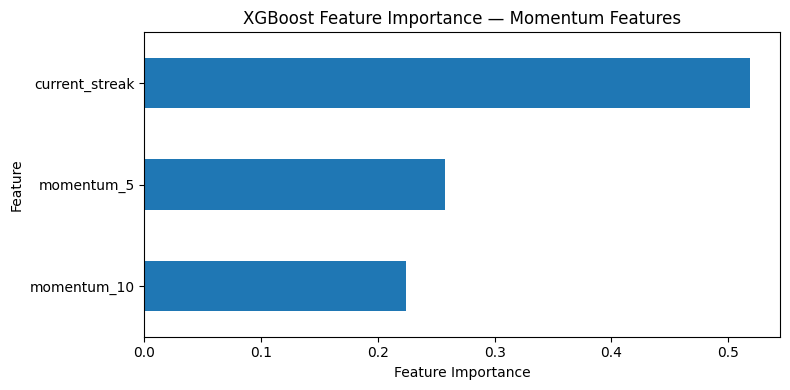

In [148]:
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_momentum.feature_importances_,
    index=X_train_momentum.columns
).sort_values()

importance.plot(kind="barh", figsize=(8, 4))

plt.title("XGBoost Feature Importance — Momentum Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [149]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic - Momentum",
        "Logistic - Full",
        "XGBoost - Momentum",
        "XGBoost - Full"
    ],
    "Accuracy": [
        0.5652676,
        0.6049293,
        0.6092630,
        0.6603889,
        0.6915932
    ],
    "ROC-AUC": [
        0.54144,
        0.6433715,
        0.6485748,
        0.7126749,
        0.7559109
    ]
})

print(results)

                 Model  Accuracy   ROC-AUC
0             Baseline  0.565268  0.541440
1  Logistic - Momentum  0.604929  0.643371
2      Logistic - Full  0.609263  0.648575
3   XGBoost - Momentum  0.660389  0.712675
4       XGBoost - Full  0.691593  0.755911


In [150]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb_momentum,
    X_test_momentum,
    y_test,
    scoring="roc_auc",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test_momentum.columns
).sort_values(ascending=False)

print(perm_importance)

current_streak    0.158449
momentum_5        0.085907
momentum_10       0.075478
dtype: float64


In [151]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic - Momentum",
        "Logistic - Full",
        "XGBoost - Momentum",
        "XGBoost - Full"
    ],
    "Accuracy": [
        0.5652676,
        0.6049293,
        0.6092630,
        0.6603889,
        0.6915932
    ],
    "ROC-AUC": [
        0.54144,
        0.6433715,
        0.6485748,
        0.7126749,
        0.7559109
    ],
    "Log Loss": [
        0.6923,
        None,
        None,
        0.6219161,
        0.5878962
    ]
})

final_results

,Model,Accuracy,ROC-AUC,Log Loss
0,Baseline,0.565268,0.541440,0.692300
1,Logistic - Momentum,0.604929,0.643371,NaN
2,Logistic - Full,0.609263,0.648575,NaN
3,XGBoost - Momentum,0.660389,0.712675,0.621916
4,XGBoost - Full,0.691593,0.755911,0.587896


In [152]:
shift_features = [
    "momentum_5",
    "momentum_10",
    "current_streak",
    "game_score_diff",
    "set_score_diff",
    "momentum_delta",
    "sign_flip"
]

X_train_shift = train_df[shift_features]
X_test_shift = test_df[shift_features]

y_train_shift = train_df["game_winner"]
y_test_shift = test_df["game_winner"]

print(X_train_shift.shape)
print(X_test_shift.shape)

(407635, 7)
(104761, 7)


In [153]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

xgb_shift = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_shift.fit(X_train_shift, y_train_shift)

y_pred_shift = xgb_shift.predict(X_test_shift)
y_prob_shift = xgb_shift.predict_proba(X_test_shift)[:, 1]

xgb_shift_accuracy = accuracy_score(y_test_shift, y_pred_shift)
xgb_shift_auc = roc_auc_score(y_test_shift, y_prob_shift)
xgb_shift_logloss = log_loss(y_test_shift, y_prob_shift)

print("XGBoost + Momentum Shifts Accuracy:", xgb_shift_accuracy)
print("XGBoost + Momentum Shifts ROC-AUC:", xgb_shift_auc)
print("XGBoost + Momentum Shifts Log Loss:", xgb_shift_logloss)

XGBoost + Momentum Shifts Accuracy: 0.6896745926442092
XGBoost + Momentum Shifts ROC-AUC: 0.7548488151366384
XGBoost + Momentum Shifts Log Loss: 0.5886115671997428
